In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib as mpl
from matplotlib import rcParams
from datetime import datetime
today = datetime.today().strftime('%Y-%m-%d')

#### Plot settings: 
rcParams['font.family'] = 'serif'
rcParams['mathtext.fontset'] = 'cm'
rcParams['mathtext.rm'] = 'serif'
mpl.rcParams["figure.dpi"] = 350
plt.rcParams['hatch.linewidth'] = 0.35

### Define any needed functions or constants: 

In [2]:
### Conditional mean rain rate: 
def conditional_mean(rate, thresh=0.1):
    out = np.zeros(rate.shape[0])
    for t in range(rate.shape[0]):
        mask = rate[t] > thresh
        out[t] = np.nanmean(rate[t][mask]) if mask.sum() > 0 else 0.
    return out

### Rain area fraction:
def rain_area_frac(rate, thresh=0.1):
    return np.mean(rate > thresh, axis=(1, 2)) * 100

### Open the data: 

In [3]:
variables = ['rain', 'prate', 'qr', 'qc', 'qv']
path = '/glade/u/home/mfranke/work/CM1/casper/derecho_comp/cm1r21.1/cm1.runs/Simulations/'
version = 'v455'

### Open the files: 
ds_ctrl = xr.open_dataset(path + f'cm1out_ctrl_{version}_1600.nc', decode_timedelta = True).isel(time=slice(0, 81))[variables]
ds_lens = xr.open_dataset(path + f'cm1out_lens_{version}_1600.nc', decode_timedelta = True).isel(time=slice(0, 81))[variables]
ds_crh = xr.open_dataset(path + f'cm1out_lens_{version}_1600_constantRH_20hrs.nc', decode_timedelta = True)[variables]

datasets = {
    'CTRL' : ds_ctrl,
    'LENS2' : ds_lens,
    'CRH' : ds_crh}

### Set the time dimension: 
time = ds_ctrl.time 
time_minutes = time.values / np.timedelta64(1, 'm')
xh = ds_ctrl['xh'].values
yh = ds_ctrl['yh'].values

### Compute the diagnostics:

In [4]:
### Initialize empty dictionaries:
domain_mean_prate = {label: [] for label in datasets}
domain_max_prate = {label: [] for label in datasets}
cond_mean_prate = {label: [] for label in datasets}
area_frac = {label: [] for label in datasets}
accum_rain = {label: [] for label in datasets}

### Compute the diagnostics: 
for label, dsr in datasets.items():
    ### Rainrate diagnostics: 
    prate_mm = (dsr['prate'] * 3600).values  
    domain_mean_prate[label] = np.nanmean(prate_mm, axis=(1, 2))
    domain_max_prate[label]  = np.nanmax(prate_mm, axis=(1, 2))
    cond_mean_prate[label]   = conditional_mean(prate_mm)

    ### Rain area fraction: 
    area_frac[label] = rain_area_frac(prate_mm)
    
    ### Accumulated rainfall diagnostics: 
    accum_rain_mm = (dsr['rain'] * 10).values
    accum_rain[label] = np.nanmean(accum_rain_mm, axis = (1,2))

### Save the final accumulated rainfall times: 
final_ctrl  = datasets['CTRL']['rain'][-1,:,:]
final_lens2 = datasets['LENS2']['rain'][-1,:,:]
final_crh = datasets['CRH']['rain'][-1,:,:]

### Plotting: 

/glade/derecho/scratch/mfranke/tmp/ipykernel_8432/2439007370.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize = fs_legend)
/glade/derecho/scratch/mfranke/tmp/ipykernel_8432/2439007370.py:107: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


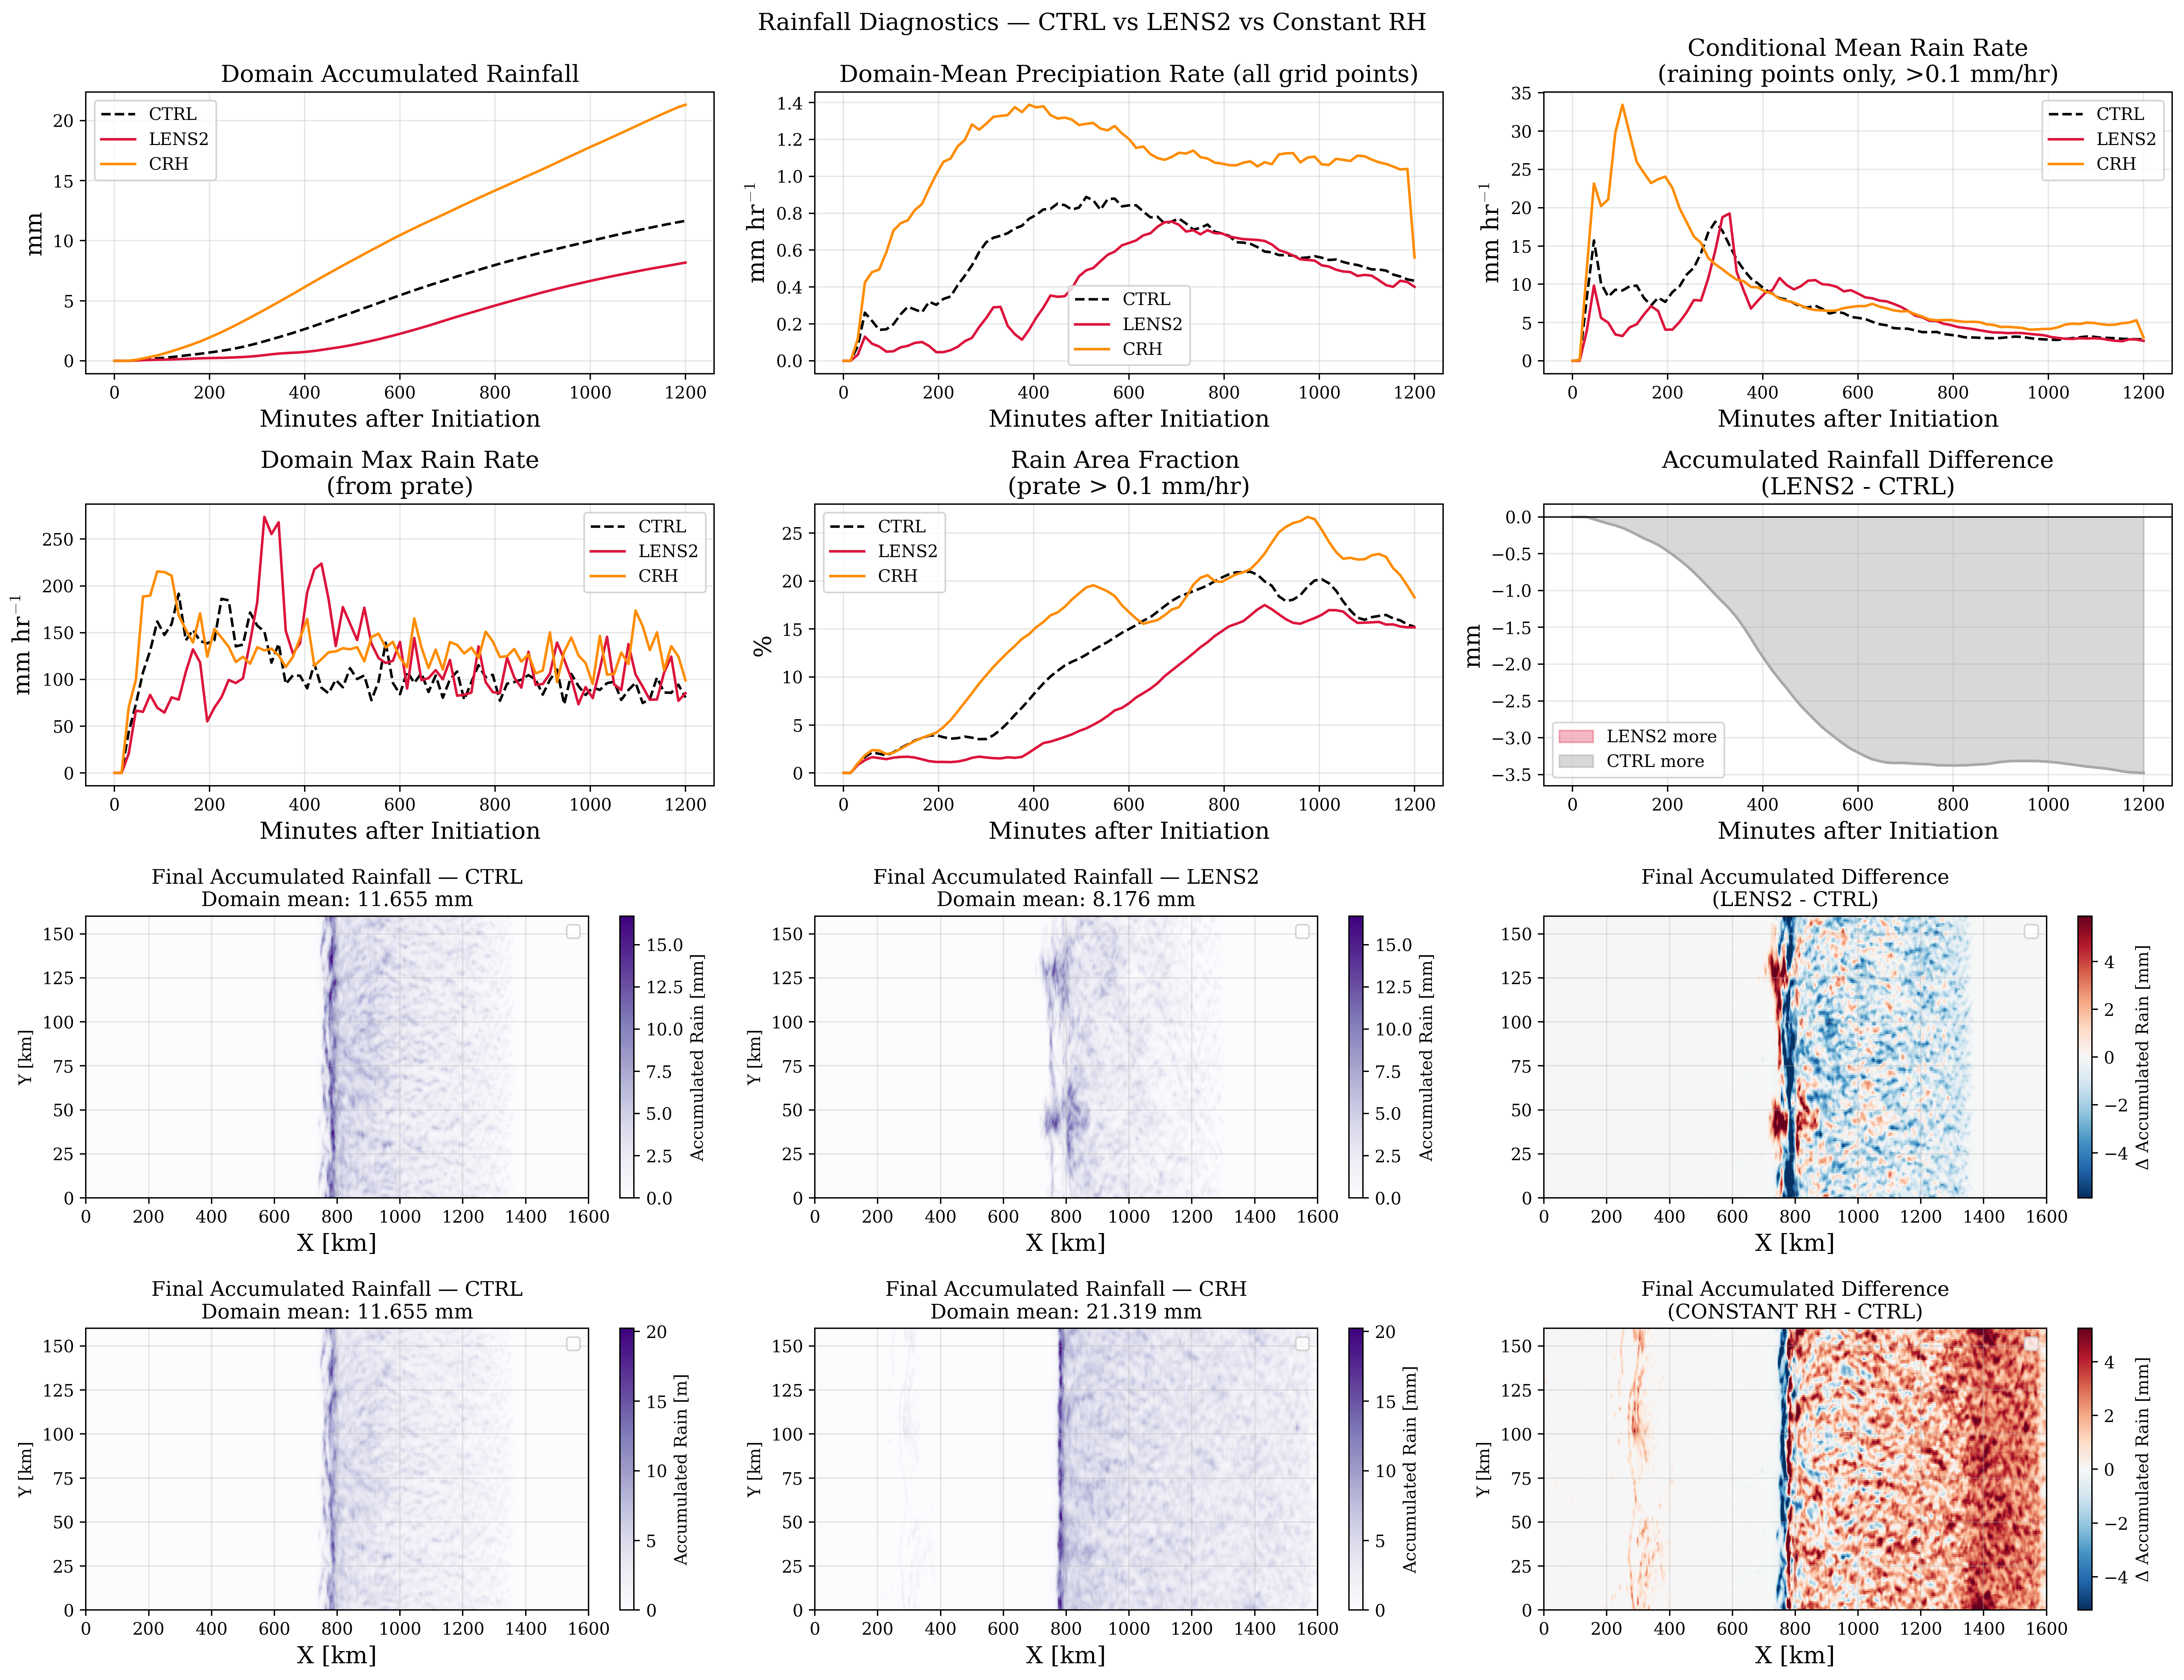

In [19]:
### Plot settings: 
colors = {'CTRL': 'black', 'LENS2': 'crimson', 'CRH': 'darkorange'}
styles = {'CTRL': '--', 'LENS2': '-', 'CRH': '-'}

fs_subtitle = 14
fs_legend = 10
fs_axislabel = 14

hspace = .5   ## Vertical spacing
wspace = .2   ## Horizontal spacing
###======================================= Time Series Plots:
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.flatten()
for label in datasets:
    axes[0].plot(time_minutes, accum_rain[label], styles[label], color=colors[label], label=label)
    axes[1].plot(time_minutes, domain_mean_prate[label],  styles[label], color=colors[label], label=label)
    axes[2].plot(time_minutes, cond_mean_prate[label], styles[label], color = colors[label], label = label)
    axes[3].plot(time_minutes, domain_max_prate[label], styles[label], color = colors[label], label = label)
    axes[4].plot(time_minutes, area_frac[label], styles[label], color = colors[label], label = label)
    axes[5].plot(time_minutes, accum_rain['LENS2'] - accum_rain['CTRL'], color = 'darkgrey')

### Compute the difference between the CTRL and LENS rainfall accumulation:
diff_accum = accum_rain['LENS2'] - accum_rain['CTRL']
axes[5].fill_between(time_minutes.astype(float), accum_rain['LENS2'] - accum_rain['CTRL'], 0,
            where=(diff_accum > 0), color='crimson', alpha=0.3, label='LENS2 more')
axes[5].fill_between(time_minutes.astype(float), accum_rain['LENS2'] - accum_rain['CTRL'], 0,
            where=(diff_accum < 0), color='grey', alpha=0.3, label='CTRL more')
axes[5].axhline(0, color='k', lw=0.8)

### Other plot attributes: 
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize = fs_legend)
    ax.set_xlabel('Minutes after Initiation', fontsize = fs_axislabel)
fig.tight_layout()
plt.subplots_adjust(hspace = hspace, wspace = wspace) 


### Set the titles and other details: 
axes[0].set_title(f'Domain Accumulated Rainfall', fontsize = fs_subtitle)
axes[0].set_ylabel('mm', fontsize = fs_axislabel)
axes[1].set_title(f'Domain-Mean Precipiation Rate (all grid points)', fontsize = fs_subtitle)
axes[1].set_ylabel('mm hr$^{-1}$', fontsize = fs_axislabel)
axes[2].set_title(f'Conditional Mean Rain Rate\n(raining points only, >0.1 mm/hr)', fontsize = fs_subtitle)
axes[2].set_ylabel('mm hr$^{-1}$', fontsize = fs_axislabel)
axes[3].set_title(f'Domain Max Rain Rate\n(from prate)', fontsize = fs_subtitle)
axes[3].set_ylabel('mm hr$^{-1}$', fontsize = fs_axislabel)
axes[4].set_title(f'Rain Area Fraction \n(prate > 0.1 mm/hr)', fontsize = fs_subtitle)
axes[4].set_ylabel('%', fontsize = fs_axislabel)
axes[5].set_title(f'Accumulated Rainfall Difference\n(LENS2 - CTRL)', fontsize = fs_subtitle)
axes[5].set_ylabel('mm', fontsize = fs_axislabel)

###======================================= XY Spatial Plots:
###==== For CTRL and LENS2:
### Set the max for the colorbar: 
vmax_map = max(final_ctrl.max(), final_lens2.max())

### Final accumulated map — CTRL:
im = axes[6].pcolormesh(xh, yh, final_ctrl, cmap='Purples', vmin=0, vmax=vmax_map)
plt.colorbar(im, ax=axes[6], label='Accumulated Rain [mm]')
axes[6].set_xlabel('X [km]')
axes[6].set_ylabel('Y [km]')
axes[6].set_title(f"Final Accumulated Rainfall — CTRL\nDomain mean: {accum_rain['CTRL'][-1]:.3f} mm")

### Final accumulated map — LENS2:
im = axes[7].pcolormesh(xh, yh, final_lens2, cmap='Purples', vmin=0, vmax=vmax_map)
plt.colorbar(im, ax=axes[7], label='Accumulated Rain [mm]')
axes[7].set_xlabel('X [km]')
axes[7].set_ylabel('Y [km]')
axes[7].set_title(f"Final Accumulated Rainfall — LENS2\nDomain mean: {accum_rain['LENS2'][-1]:.3f} mm")

### Final accumulated difference map:
diff_map = final_lens2 - final_ctrl
vmax_diff = np.percentile(np.abs(diff_map), 99)
im = axes[8].pcolormesh(xh, yh, diff_map, cmap='RdBu_r', vmin=-vmax_diff, vmax=vmax_diff)
plt.colorbar(im, ax=axes[8], label='\u0394 Accumulated Rain [mm]')
axes[8].set_xlabel('X [km]'); ax.set_ylabel('Y [km]')
axes[8].set_title('Final Accumulated Difference\n(LENS2 - CTRL)')

###==== For CTRL and CRH:
### Set the max for the colorbar: 
vmax_map = max(final_ctrl.max(), final_crh.max())

### Final accumulated map: CTRL
im = axes[9].pcolormesh(xh, yh, final_ctrl, cmap='Purples', vmin=0, vmax=vmax_map)
plt.colorbar(im, ax=axes[9], label='Accumulated Rain [m]')
axes[9].set_xlabel('X [km]')
axes[9].set_ylabel('Y [km]')
axes[9].set_title(f"Final Accumulated Rainfall — CTRL\nDomain mean: {accum_rain['CTRL'][-1]:.3f} mm")

### Final accumulated map — CRH
im = axes[10].pcolormesh(xh, yh, final_crh, cmap='Purples', vmin=0, vmax=vmax_map)
plt.colorbar(im, ax=axes[10], label='Accumulated Rain [mm]')
axes[10].set_xlabel('X [km]')
axes[10].set_ylabel('Y [km]')
axes[10].set_title(f"Final Accumulated Rainfall — CRH\nDomain mean: {accum_rain['CRH'][-1]:.3f} mm")

### Final accumulated difference map:
diff_map = final_crh - final_ctrl
vmax_diff = np.percentile(np.abs(diff_map), 99)
im = axes[11].pcolormesh(xh, yh, diff_map, cmap='RdBu_r', vmin=-vmax_diff, vmax=vmax_diff)
plt.colorbar(im, ax=axes[11], label='\u0394 Accumulated Rain [mm]')
axes[11].set_xlabel('X [km]')
axes[11].set_ylabel('Y [km]')
axes[11].set_title('Final Accumulated Difference\n(CONSTANT RH - CTRL)')

plt.suptitle('Rainfall Diagnostics — CTRL vs LENS2 vs Constant RH', fontsize=14)
plt.tight_layout()

### Save figure: 
# plt.savefig('./Figures/rainfall_prate_diagnostics.jpg', bbox_inches = 'tight')


In [24]:
### Summary: 
print("\n=== Summary ===")
print(f"CTRL  domain-mean total accumulated: {accum_rain['CTRL'][-1]:.4f} mm")
print(f"LENS2 domain-mean total accumulated: {accum_rain['LENS2'][-1]:.4f} mm")
print(f"Difference (LENS2 - CTRL):           {accum_rain['LENS2'][-1] - accum_rain['CTRL'][-1]:.4f} mm")
print(f"Percent difference:                  {(accum_rain['LENS2'][-1] - accum_rain['CTRL'][-1])/accum_rain['CTRL'][-1]*100:.1f}%")

print(f"CRH domain-mean total accumulated: {accum_rain['CRH'][-1]:.4f} mm")
print(f"Difference (CRH - CTRL):           {accum_rain['CRH'][-1] - accum_rain['CTRL'][-1]:.4f} mm")
print(f"Percent difference:                  {(accum_rain['CRH'][-1] - accum_rain['CTRL'][-1])/accum_rain['CTRL'][-1]*100:.1f}%")

print(f"\nCTRL  time-mean domain-mean prate:   {domain_mean_prate['CTRL'].mean():.2f} mm/hr")
print(f"LENS2 time-mean domain-mean prate:   {domain_mean_prate['LENS2'].mean():.2f} mm/hr")
print(f"CRH time-mean domain-mean prate:   {domain_mean_prate['CRH'].mean():.2f} mm/hr")

print(f"\nCTRL  overall max prate:             {domain_max_prate['CTRL'].max():.1f} mm/hr")
print(f"LENS2 overall max prate:             {domain_max_prate['LENS2'].max():.1f} mm/hr")
print(f"CRH overall max prate:             {domain_max_prate['CRH'].max():.1f} mm/hr")

print(f"\nCTRL  time-mean rain area fraction:  {area_frac['CTRL'].mean():.1f}%")
print(f"LENS2 time-mean rain area fraction:  {area_frac['LENS2'].mean():.1f}%")
print(f"CRH time-mean rain area fraction:  {area_frac['CRH'].mean():.1f}%")

print(f"\nCTRL  time-mean conditional mean:    {cond_mean_prate['CTRL'].mean():.2f} mm/hr")
print(f"LENS2 time-mean conditional mean:    {cond_mean_prate['LENS2'].mean():.2f} mm/hr")
print(f"CRH time-mean conditional mean:    {cond_mean_prate['CRH'].mean():.2f} mm/hr")



=== Summary ===
CTRL  domain-mean total accumulated: 11.6549 mm
LENS2 domain-mean total accumulated: 8.1765 mm
Difference (LENS2 - CTRL):           -3.4785 mm
Percent difference:                  -29.8%
CRH domain-mean total accumulated: 21.3193 mm
Difference (CRH - CTRL):           9.6644 mm
Percent difference:                  82.9%

CTRL  time-mean domain-mean prate:   0.58 mm/hr
LENS2 time-mean domain-mean prate:   0.41 mm/hr
CRH time-mean domain-mean prate:   1.06 mm/hr

CTRL  overall max prate:             191.6 mm/hr
LENS2 overall max prate:             273.8 mm/hr
CRH overall max prate:             215.5 mm/hr

CTRL  time-mean rain area fraction:  12.2%
LENS2 time-mean rain area fraction:  8.4%
CRH time-mean rain area fraction:  15.6%

CTRL  time-mean conditional mean:    6.37 mm/hr
LENS2 time-mean conditional mean:    6.21 mm/hr
CRH time-mean conditional mean:    9.65 mm/hr
